# Assignment 2: Building Detection from Satellite Imagery (YOLOv8)

This notebook follows all assignment steps:
1. Environment setup
2. Dataset download
3. Dataset exploration
4. Train/Val/Test split
5. YOLOv8 training
6. Evaluation
7. Building-count pipeline
8. Report content


In [1]:

!pip install -q ultralytics kaggle

import torch
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Device:", torch.cuda.get_device_name(0))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 34.2 MB/s eta 0:00:00
GPU available: True
Device: Tesla T4


## Step 1: Download Dataset from Kaggle

In [2]:


!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d pallav23/icg-spacenet-sandox-yolo
!unzip -q icg-spacenet-sandox-yolo.zip -d /content/data


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/pallav23/icg-spacenet-sandox-yolo
License(s): CC-BY-SA-4.0
100% 950M/950M [00:10<00:00, 95.0MB/s]



## Step 2.1 Count Images

In [3]:

import glob

images = glob.glob('/content/data/**/*.png', recursive=True)
labels = glob.glob('/content/data/**/*.txt', recursive=True)

print("Images:", len(images))
print("Labels:", len(labels))


Images: 1148
Labels: 1148


## Step 2.2 Visualize 9 Random Images with Bounding Boxes

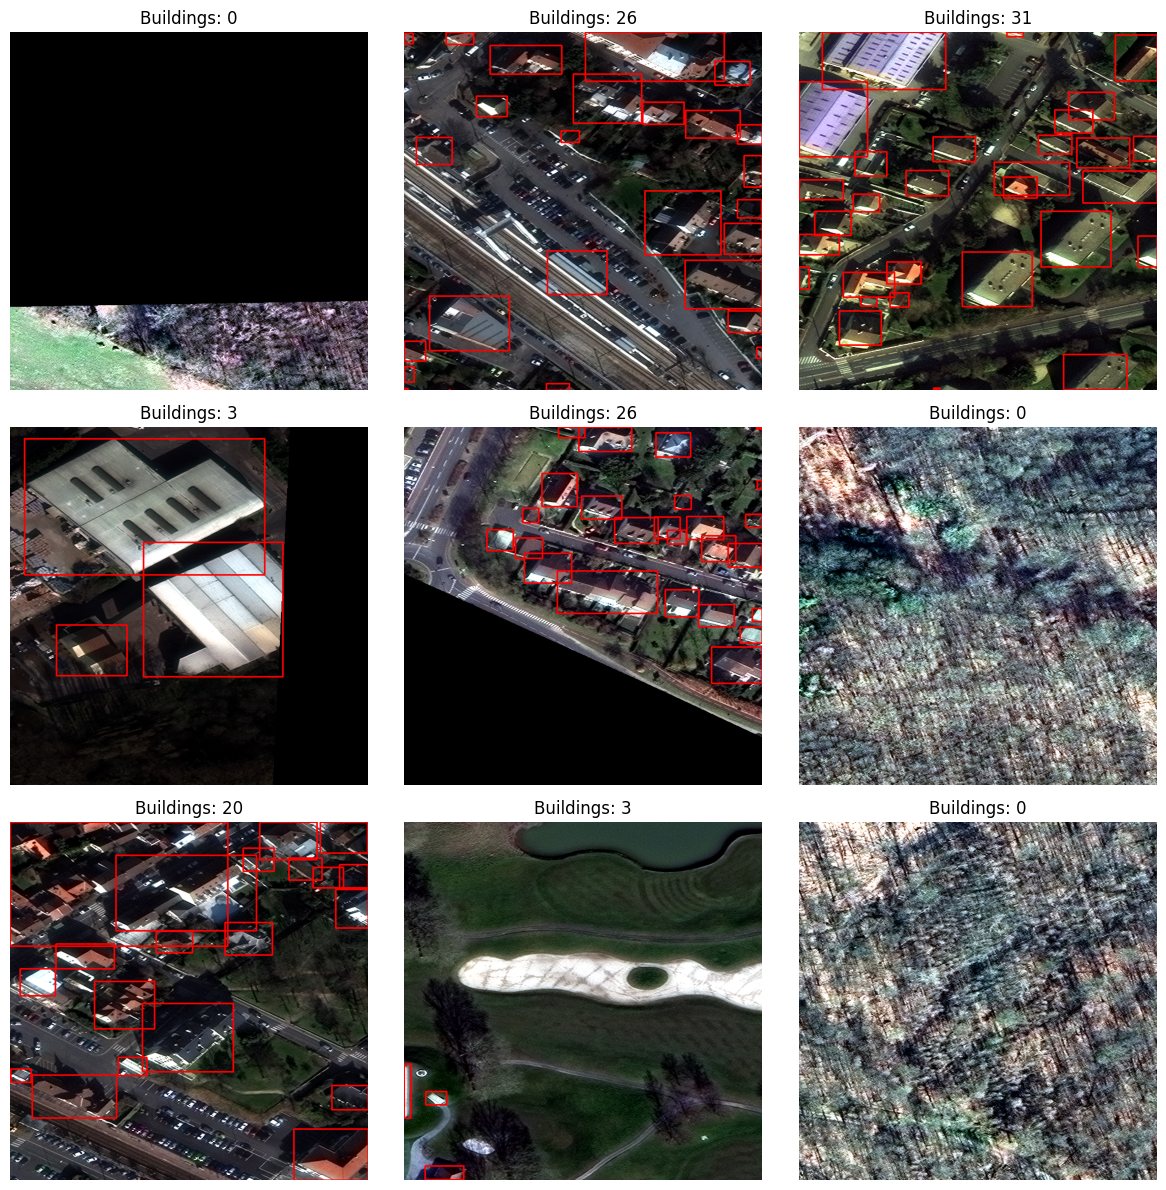

In [4]:

import random
import cv2
import matplotlib.pyplot as plt
import os

sample_imgs = random.sample(images, 9)

fig, axes = plt.subplots(3,3, figsize=(12,12))

for ax, img_path in zip(axes.ravel(), sample_imgs):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    label_path = img_path.replace('images','labels').replace('.png','.txt')

    count = 0

    if os.path.exists(label_path):
        with open(label_path) as f:
            lines = f.readlines()

        count = len(lines)

        for line in lines:
            cls,cx,cy,bw,bh = map(float,line.split())

            x1 = int((cx-bw/2)*w)
            y1 = int((cy-bh/2)*h)
            x2 = int((cx+bw/2)*w)
            y2 = int((cy+bh/2)*h)

            cv2.rectangle(img,(x1,y1),(x2,y2),(255,0,0),2)

    ax.imshow(img)
    ax.set_title(f"Buildings: {count}")
    ax.axis('off')

plt.tight_layout()
plt.show()


## Step 2.3 Answers

### Average Buildings per Image
Run the next cell to compute it.

### Image Consistency
Most satellite images generally have similar resolution and viewing angle.

### Expected Challenges
* Dense building clusters
* Tiny rooftops
* Occlusions
* Shadows
* Similar-looking background structures


In [5]:

total_buildings = 0

for lbl in labels:
    with open(lbl) as f:
        total_buildings += len(f.readlines())

print("Average buildings/image =", total_buildings/len(images))


Average buildings/image = 14.488675958188153


## Step 3: Create Train / Validation / Test Split

In [6]:

import os
import shutil
import random
from pathlib import Path

random.seed(42)

BASE='/content/dataset'

for folder in [
    'images/train','images/val','images/test',
    'labels/train','labels/val','labels/test'
]:
    os.makedirs(os.path.join(BASE,folder), exist_ok=True)

random.shuffle(images)

n=len(images)
train_cut=int(0.8*n)
val_cut=int(0.9*n)

splits={
    'train':images[:train_cut],
    'val':images[train_cut:val_cut],
    'test':images[val_cut:]
}

for split,imgs in splits.items():

    for img_path in imgs:

        stem=Path(img_path).stem

        lbl_path=img_path.replace('images','labels').replace('.png','.txt')

        shutil.copy(img_path,f'{BASE}/images/{split}/{stem}.png')

        dst=f'{BASE}/labels/{split}/{stem}.txt'

        if os.path.exists(lbl_path):
            shutil.copy(lbl_path,dst)
        else:
            open(dst,'w').close()

for k,v in splits.items():
    print(k,len(v))


train 918
val 115
test 115


## Create dataset.yaml

In [7]:

yaml_text='''
path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 1
names: ['building']
'''

with open('/content/dataset.yaml','w') as f:
    f.write(yaml_text)

print(open('/content/dataset.yaml').read())



path: /content/dataset
train: images/train
val: images/val
test: images/test

nc: 1
names: ['building']



## Step 4.1 Why use yolov8s.pt?

YOLOv8s.pt contains pretrained weights learned from a large dataset. Starting from pretrained weights allows faster convergence, better feature extraction, and higher accuracy than training from random initialization.


## Step 4.2 Train YOLOv8

In [8]:

from ultralytics import YOLO

model = YOLO('yolov8s.pt')

results = model.train(
    data='/content/dataset.yaml',
    epochs=25,
    imgsz=640,
    batch=16,
    project='runs/detect',
    name='building_detector'
)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640

In [13]:

import pandas as pd

df = pd.read_csv('runs/detect/runs/detect/building_detector/results.csv')

print("Final box loss:", df['train/box_loss'].iloc[-1])

map_cols=[c for c in df.columns if 'mAP50' in c]
print(df[map_cols].tail(1))


Final box loss: 1.22923
    metrics/mAP50(B)  metrics/mAP50-95(B)
24           0.79308              0.48691


## Step 4.3 Training Curves

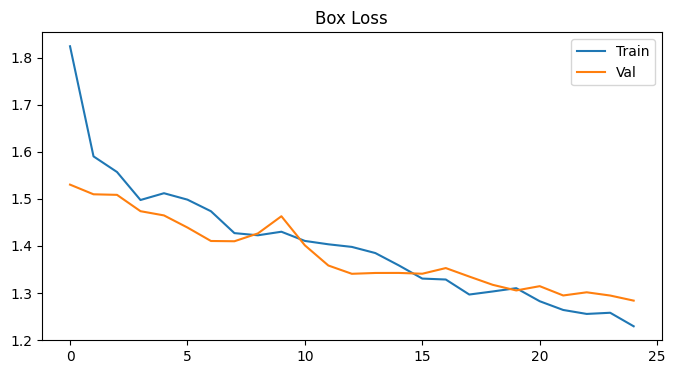

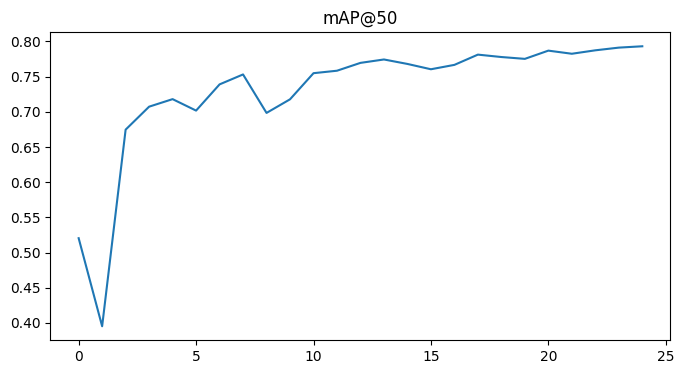

In [15]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('runs/detect/runs/detect/building_detector/results.csv')

plt.figure(figsize=(8,4))
plt.plot(df['train/box_loss'], label='Train')
plt.plot(df['val/box_loss'], label='Val')
plt.legend()
plt.title('Box Loss')
plt.show()

map_col=[c for c in df.columns if 'mAP50(B)' in c][0]

plt.figure(figsize=(8,4))
plt.plot(df[map_col])
plt.title('mAP@50')
plt.show()


### Observation

Describe:
* Whether validation loss follows training loss.
* Whether mAP plateaued or continued improving.


## Step 5 Evaluation

In [16]:

metrics = model.val(data='/content/dataset.yaml')

precision = metrics.box.p
recall = metrics.box.r
map50 = metrics.box.map50

f1 = 2*precision*recall/(precision+recall)

print("mAP50 =", map50)
print("Precision =", precision)
print("Recall =", recall)
print("F1 =", f1)


Ultralytics 8.4.64 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 4207.4±738.3 MB/s, size: 939.7 KB)
val: Scanning /content/dataset/labels/val.cache... 115 images, 58 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 115/115 34.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 1.2it/s 6.6s
                   all        115       1445       0.79      0.734      0.794      0.487
Speed: 6.7ms preprocess, 12.0ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to /content/runs/detect/val
mAP50 = 0.7935569340036758
Precision = [    0.78951]
Recall = [    0.73426]
F1 = [    0.76088]


Confusion Matrix and Precision-Recall Curve are automatically generated inside the runs folder.

## Step 6.1 Reusable Detection Function

In [17]:

import time

def detect_buildings(image_path):

    start=time.time()

    result=model.predict(image_path, verbose=False)[0]

    count=len(result.boxes)

    conf=0
    if count:
        conf=float(result.boxes.conf.mean())

    runtime=(time.time()-start)*1000

    return count, conf, runtime, result


MAE = 2.3


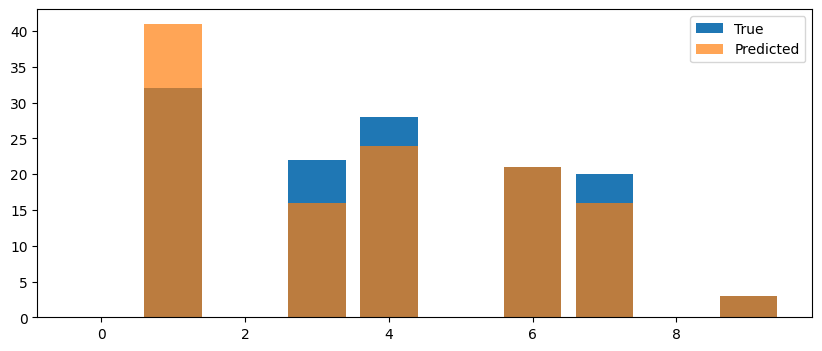

In [18]:

import numpy as np
import matplotlib.pyplot as plt

test_imgs=glob.glob('/content/dataset/images/test/*.png')[:10]

true_counts=[]
pred_counts=[]

for img in test_imgs:

    label=img.replace('/images/','/labels/').replace('.png','.txt')

    true_count=sum(1 for _ in open(label))

    pred_count,_,_,_=detect_buildings(img)

    true_counts.append(true_count)
    pred_counts.append(pred_count)

mae=np.mean(np.abs(np.array(true_counts)-np.array(pred_counts)))
print("MAE =", mae)

plt.figure(figsize=(10,4))
x=range(len(test_imgs))

plt.bar(x,true_counts,label='True')
plt.bar(x,pred_counts,label='Predicted',alpha=0.7)

plt.legend()
plt.show()


## Step 6.2 End-to-End Pipeline

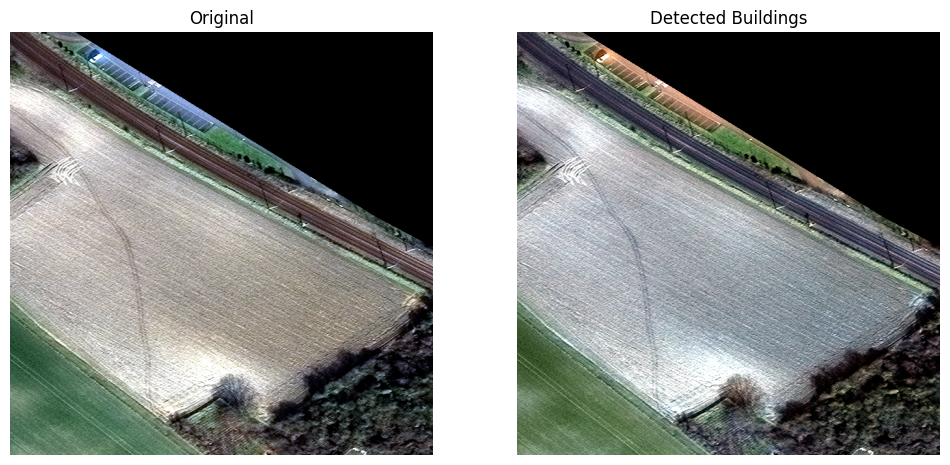

Image: AOI_3_Paris_img52.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 33.84 ms


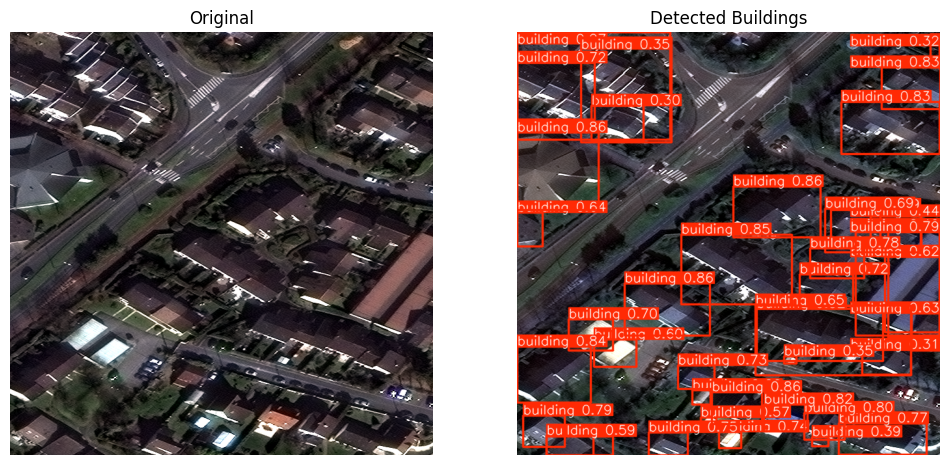

Image: AOI_3_Paris_img214.png
Buildings detected: 41
Avg confidence: 0.63
Processing time: 40.65 ms


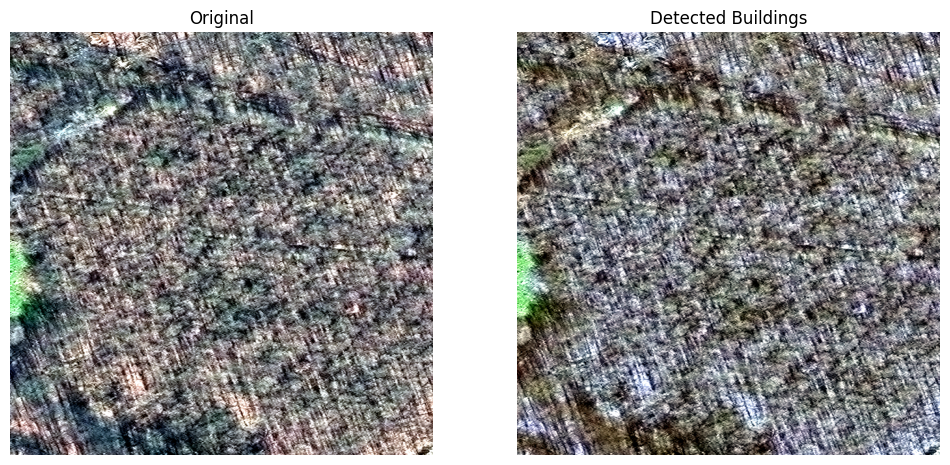

Image: AOI_3_Paris_img491.png
Buildings detected: 0
Avg confidence: 0.00
Processing time: 39.28 ms


In [21]:

import matplotlib.pyplot as plt

def full_pipeline(image_path):

    count,conf,runtime,result=detect_buildings(image_path)

    annotated=result.plot()

    fig,ax=plt.subplots(1,2,figsize=(12,6))

    original=plt.imread(image_path)

    ax[0].imshow(original)
    ax[0].set_title('Original')
    ax[0].axis('off')

    ax[1].imshow(annotated)
    ax[1].set_title('Detected Buildings')
    ax[1].axis('off')

    plt.show()

    print(f'Image: {image_path.split("/")[-1]}')
    print(f'Buildings detected: {count}')
    print(f'Avg confidence: {conf:.2f}')
    print(f'Processing time: {runtime:.2f} ms')

for img in test_imgs[:3]:
    full_pipeline(img)
